# Step 2a — Disparity filter

Turn the raw walk trajectories from `02_semantic_walk.ipynb` into training sentences using a **per-anchor adaptive threshold**, the fourth of four threshold methods (alongside `02a_filter_constant_theta.ipynb`, `02a_filter_pct_dropoff.ipynb`, and `02a_filter_kneedle.ipynb`). This one adapts Serrano, Boguñá and Vespignani's **disparity filter** (PNAS 2009): treat each anchor as a hub node whose edges are its positive cosine similarities to every other product, and keep only the edges that are statistically significant against a null model of how a node's total strength would spread across its edges by chance. The similarity at the significance boundary becomes that anchor's own `theta`. Then, exactly like the three sibling filters, we rebuild `sentence = [anchor] + [every raw_path[i+1] whose raw_sims[i] >= theta_anchor]` and keep sentences with at least `min_sentence_length` products.

Where `pct_dropoff` and Kneedle only ever look at the **shape** of one ranked curve, this method is the first of the four to factor in the anchor's own **connectivity**: how many genuine candidates it has (degree `k`) and how concentrated its similarity strength is among them. That is a structurally different signal neither prior method can see.

The threshold decides only what gets **logged**, never where the walk went — every filter notebook reads the same `walk_raw_paths.jsonl`, so all four methods are compared on identical trajectories.

**Inputs** (in `outputs/`)
- `walk_raw_paths.jsonl` — raw walks (`anchor_id`, `raw_path`, `raw_sims`, `hops_taken`)
- `walk_config.json` — the walk run this filter is built on (for traceability)
- `product_basket_freq.json` — per-product basket counts for the popularity check
- `embeddings.npy` + `product_id_to_index.json` — Step 1 vectors, used **here to compute the adaptive thresholds themselves** (not only for the rank-novelty diagnostic); `products_text.csv` for product names

**Outputs** (to `outputs/`)
- `filters/disparity/alpha_0.05/thresholds.json` — per-anchor `{theta, k, n_significant, fallback}`
- `filters/disparity/alpha_0.05/walk_sentences.jsonl` — one kept sentence per line
- `filters/disparity/alpha_0.05/filter_config.json` — method, alpha_level, min length, timestamps
- `filters/disparity/alpha_0.05/walk_sentences_readable.txt` — human-readable kept sentences

No extra dependency — plain numpy covers this method entirely.

## 1. Imports and paths

Paths are resolved relative to the project root so the notebook works regardless of where Jupyter is launched from.

In [1]:
import json
import time
import datetime
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
STEP1_DIR = OUT_DIR / "step1"

print("Data dir:   ", DATA_DIR)
print("Outputs dir:", OUT_DIR)

Data dir:    /Users/linnhtet/Developer/bachelor-thesis/data
Outputs dir: /Users/linnhtet/Developer/bachelor-thesis/outputs


## 2. Parameters

The filter has one knob, the significance level `ALPHA_LEVEL`, kept here as a named constant (same reasoning as `DROP_PCT` / `KNEE_SENSITIVITY` in the siblings) so it is easy to sweep later. There is no single `theta` — each anchor gets its own, computed in §4 — except when no candidate is significant, where the method falls back to the constant baseline.

In [2]:
METHOD_NAME = "disparity"
VALUE_LABEL = "alpha_0.05"
FILTER_DIR = OUT_DIR / "filters" / METHOD_NAME / VALUE_LABEL
FILTER_DIR.mkdir(parents=True, exist_ok=True)

# ---- Adaptive threshold rule ----
ALPHA_LEVEL = 0.05   # standard significance level from the disparity filter
                     # literature. Kept as a named, sweepable constant, same
                     # reasoning as DROP_PCT / KNEE_SENSITIVITY.

CONSTANT_THETA_BASELINE = 0.70   # comparison baseline; ALSO the fallback theta
                                 # when no candidate is significant (see §4).

min_sentence_length = 2    # discard sentences shorter than this (same rule as siblings)

# Stress-test anchors — must match those 02_semantic_walk.ipynb always walked.
STRESS_TEST_IDS = {
    4210:  "Whole Milk",
    6347:  "Unsweetened Almond Milk",
    651:   "Organic Salted Butter",
    16268: "Vegan Butter",
    6104:  "Whole Milk Plain Yogurt",
    920:   "Coconut Yogurt",
}

## 3. Load the raw walks and supporting artifacts

Everything this notebook needs was produced upstream: the raw walks and walk config from `02_semantic_walk.ipynb`, the per-product basket counts (so the popularity check never rebuilds the basket graph), and Step 1's embeddings + id map — used **both** to compute the per-anchor thresholds (§4) and for the rank novelty test.

In [3]:
# Raw walks from the walk notebook (one JSON object per line).
raw_walks = []
with open(OUT_DIR / "walk_raw_paths.jsonl") as f:
    for line in f:
        raw_walks.append(json.loads(line))

# The walk run this filter is built on — its timestamp is recorded for traceability.
with open(OUT_DIR / "walk_config.json") as f:
    walk_config = json.load(f)

# Per-product sampled-basket counts (for the background popularity check).
with open(OUT_DIR / "product_basket_freq.json") as f:
    freq = json.load(f)
total_baskets = freq["total_baskets"]
product_basket_count = {int(pid): c for pid, c in freq["product_basket_count"].items()}

# Step 1 artifacts: embeddings (unit-normalised) + id map for both the threshold
# computation and the rank novelty test, and product names for readable output.
embeddings = np.load(STEP1_DIR / "embeddings.npy").astype(np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / np.clip(norms, 1e-12, None)

with open(STEP1_DIR / "product_id_to_index.json") as f:
    pid_to_idx = {int(pid): row for pid, row in json.load(f).items()}

products_text = pd.read_csv(STEP1_DIR / "products_text.csv")
id_to_name = dict(zip(products_text["product_id"], products_text["product_name"]))


def name(pid):
    return id_to_name.get(int(pid), f"?{pid}")


def names(ids):
    return [name(p) for p in ids]


print(f"raw walks loaded      : {len(raw_walks):,}")
print(f"walk_config timestamp : {walk_config.get('timestamp')}")
print(f"basket counts         : {len(product_basket_count):,} products, "
      f"{total_baskets:,} total baskets")
print(f"embeddings            : {embeddings.shape}")

raw walks loaded      : 400,100
walk_config timestamp : 2026-08-08T14:06:21
basket counts         : 48,526 products, 1,000,000 total baskets
embeddings            : (49688, 384)


## 4. Rank each anchor and compute its per-anchor theta via the disparity filter

We reuse `anchor_sorted_sims` from the sibling notebooks **exactly as-is**: cosine the anchor against the whole catalogue, mask its own index to `-inf` before sorting, and sort descending, never truncated.

**The filter.** Treat the anchor as a hub node whose edges are its **positive** cosine similarities to every other product. For candidate `j` with similarity `w_j`: let `k` be the anchor's degree (how many positive-similarity candidates it has), `s` its total strength (their sum), and `p_j = w_j / s`. Under the null model that a node's strength is split at random across its `k` edges, the chance a single edge holds at least this large a share is `alpha_j = (1 - p_j) ** (k - 1)`. An edge is **significant** when `alpha_j < ALPHA_LEVEL`, and `theta` is the similarity at the significance boundary (the weakest edge that still clears it).

**Two deliberate simplifications from the original paper:**

1. **Per-anchor only**, not the paper's bidirectional either-endpoint-qualifies rule. We are independently testing each anchor's own candidates, not pruning one shared global network, so an edge only has to be significant from the anchor's side.
2. **Only positive similarities form the local network.** Negative or zero cosines are not relationships, so they are excluded from the network entirely rather than clipped to 0. Degree `k` therefore varies per anchor instead of being fixed at catalogue size. (This also drops `anchor_sorted_sims`' own `-inf` self-sentinel automatically — same effect as Kneedle's explicit filter, same reason: it is not a real edge.)

**Why this still reduces to one theta.** For fixed `k` and `s`, `alpha_j` moves monotonically with `w_j`, so the significant edges are always exactly the top-`M` by similarity for some `M` — a clean contiguous prefix, never a scattered set. That is what lets a connectivity-based method produce a single per-anchor `theta` with the same output shape as the other three, despite sharing none of their mechanics.

This is pure vectorised numpy with no external per-call library cost (unlike Kneedle), so total runtime should be close to pct_dropoff's — a single elapsed print at the end is enough, no pre-flight timing dance. We still print the six stress-test anchors first, same as always: look at the known cases before trusting the unknown ones.

In [4]:
def anchor_sorted_sims(anchor_id):
    """Full descending similarity of the whole catalogue to this anchor.

    Mask the anchor's own row to -inf BEFORE sorting: its self-similarity is 1.0
    and, left in, would look like a guaranteed rank-1 cliff for every anchor. The
    ranking is kept FULL (never truncated) — only the drop search bounds depth.
    """
    a = pid_to_idx[anchor_id]
    sims = embeddings @ embeddings[a]      # cosine vs anchor (unit-norm); fresh array
    sims[a] = -np.inf                      # mask self before sorting, not after
    return np.sort(sims)[::-1]             # descending; sorted_sims[0] = rank 1


def disparity_theta(sorted_sims):
    """Disparity-filter threshold for one anchor's full descending ranking.

    Only positive similarities form the local network (this also drops
    anchor_sorted_sims' own -inf self-sentinel automatically, same effect as
    Kneedle's explicit filter, same underlying reason: it's not a real edge).
    k = degree, s = total strength, p_j = w_j / s, alpha_j = (1-p_j)**(k-1).
    Because p_j (and alpha_j) move monotonically with w_j for fixed k and s,
    significant candidates are always exactly the top-M by similarity for some
    M — no need to test out of rank order, no risk of a non-contiguous
    significant set. This is what lets the method reduce to a single per-anchor
    theta, same output shape as the other two, despite having nothing else in
    common with either mechanically.
    """
    positive = sorted_sims[sorted_sims > 0]
    k = len(positive)
    if k < 2:
        # (1-p)**(k-1) is undefined at k=0 or trivially 1.0 for any p at k=1 —
        # nothing could ever be significant either way. Fall back.
        return {"theta": CONSTANT_THETA_BASELINE, "k": k,
                "n_significant": 0, "fallback": True}

    s = float(positive.sum())
    p = positive / s
    alpha = (1.0 - p) ** (k - 1)
    n_significant = int((alpha < ALPHA_LEVEL).sum())   # monotonic -> a clean prefix count

    if n_significant == 0:
        return {"theta": CONSTANT_THETA_BASELINE, "k": k,
                "n_significant": 0, "fallback": True}

    theta = float(positive[n_significant - 1])   # similarity at the boundary
    return {"theta": theta, "k": k,
            "n_significant": n_significant, "fallback": False}


# Only anchors that were actually walked (not the full starting_products list).
walked_anchor_ids = sorted({int(w["anchor_id"]) for w in raw_walks})
print(f"walked anchors: {len(walked_anchor_ids):,}")

walked anchors: 20,005


### Sanity check: the stress-test anchors first

Print `theta`, degree `k`, `n_significant`, and `fallback` for the six known anchors before running the full loop.

In [5]:
print("Disparity filter on the stress-test anchors:")
print("=" * 80)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"  {nm:<28} (not in catalogue)")
        continue
    res = disparity_theta(anchor_sorted_sims(pid))
    print(f"  {nm:<28} theta={res['theta']:.3f}  k={res['k']:>6}  "
          f"n_significant={res['n_significant']:>6}  fallback={res['fallback']}")

Disparity filter on the stress-test anchors:
  Whole Milk                   theta=0.984  k= 49667  n_significant=     1  fallback=False
  Unsweetened Almond Milk      theta=0.700  k= 49592  n_significant=     0  fallback=True
  Organic Salted Butter        theta=0.700  k= 49658  n_significant=     0  fallback=True
  Vegan Butter                 theta=0.700  k= 49620  n_significant=     0  fallback=True
  Whole Milk Plain Yogurt      theta=0.915  k= 49593  n_significant=     9  fallback=False
  Coconut Yogurt               theta=0.700  k= 49630  n_significant=     0  fallback=True


In [6]:
try:
    from tqdm.auto import tqdm
    anchor_iter = tqdm(walked_anchor_ids, desc="anchors")
except ImportError:
    anchor_iter = walked_anchor_ids

anchor_thresholds = {}   # anchor_id -> {"theta", "k", "n_significant", "fallback"}
n_skipped = 0
t0 = time.perf_counter()
for aid in anchor_iter:
    if aid not in pid_to_idx:
        n_skipped += 1                   # not in the Step 1 catalogue -> cannot rank
        continue
    anchor_thresholds[aid] = disparity_theta(anchor_sorted_sims(aid))
elapsed = time.perf_counter() - t0

# Convenience map for the filter step.
anchor_theta = {aid: t["theta"] for aid, t in anchor_thresholds.items()}

# ---- Headline split: significant edges found vs fallback (analogue of the others' splits) ----
n_significant_found = sum(1 for t in anchor_thresholds.values() if not t["fallback"])
n_fallback = len(anchor_thresholds) - n_significant_found
thetas_all = np.array([t["theta"] for t in anchor_thresholds.values()])
print(f"walked anchors             : {len(walked_anchor_ids):,}")
print(f"thresholds computed        : {len(anchor_thresholds):,}")
if n_skipped:
    print(f"skipped (not in catalog)   : {n_skipped:,}")
print(f"significant edges found    : {n_significant_found:,} "
      f"({100 * n_significant_found / max(len(anchor_thresholds), 1):.1f}%)")
print(f"fell back to baseline      : {n_fallback:,} "
      f"({100 * n_fallback / max(len(anchor_thresholds), 1):.1f}%)")
if len(thetas_all):
    print(f"theta mean/median/min/max  : {thetas_all.mean():.3f} / "
          f"{np.median(thetas_all):.3f} / {thetas_all.min():.3f} / {thetas_all.max():.3f}")

# ---- Degree (k) distribution across ALL anchors ----
# A genuinely open empirical question: if k runs to the tens of thousands for most
# anchors, that is very different from the sparse networks the disparity filter was
# designed for, and worth knowing before trusting the results.
ks = np.array([t["k"] for t in anchor_thresholds.values()])
if len(ks):
    print(f"degree k min/median/max    : {ks.min()} / {int(np.median(ks))} / {ks.max()}  "
          f"(positive-similarity candidates per anchor)")

# ---- n_significant distribution among non-fallback anchors ----
nsig = np.array([t["n_significant"] for t in anchor_thresholds.values() if not t["fallback"]])
if len(nsig):
    print(f"n_significant min/median/max: {nsig.min()} / {int(np.median(nsig))} / {nsig.max()}  "
          f"(non-fallback anchors only)")
else:
    print("n_significant distribution : (no significant edges found for any anchor)")

print(f"elapsed                    : {elapsed:.1f}s")

# Save the per-anchor thresholds (useful on its own, independent of filtering below).
thresholds_path = FILTER_DIR / "thresholds.json"
with open(thresholds_path, "w") as f:
    json.dump({str(aid): t for aid, t in anchor_thresholds.items()}, f)
print("Saved", thresholds_path.name)

/Users/linnhtet/Developer/bachelor-thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
anchors: 100%|████████████████████████████| 20005/20005 [00:45<00:00, 441.22it/s]


walked anchors             : 20,005
thresholds computed        : 20,005
significant edges found    : 10,621 (53.1%)
fell back to baseline      : 9,384 (46.9%)
theta mean/median/min/max  : 0.731 / 0.700 / 0.169 / 1.000
degree k min/median/max    : 28144 / 49610 / 49686  (positive-similarity candidates per anchor)
n_significant min/median/max: 1 / 14 / 2466  (non-fallback anchors only)
elapsed                    : 45.3s
Saved disparity_thresholds.json


## 5. Apply the per-anchor filter

Same mechanism as the sibling filters, except each walk is filtered against **its own anchor's** `theta` from §4 rather than one global value. Since `raw_sims[i]` is the similarity for `raw_path[i + 1]`, this is a direct zip of `raw_path[1:]` against `raw_sims`. Keep only sentences with `>= min_sentence_length` products.

In [7]:
def filter_walk(w, theta):
    """Rebuild a sentence from a raw walk: anchor + every winner with raw_sim >= theta."""
    sentence = [w["anchor_id"]]
    for nxt, sim in zip(w["raw_path"][1:], w["raw_sims"]):
        if sim >= theta:
            sentence.append(nxt)
    return sentence


filtered = []          # {"anchor_id", "raw_path", "sentence", "hops_taken"} for every filtered walk
kept_sentences = []    # {"anchor_id", "sentence"} for the kept ones only
n_total = 0
n_discarded = 0
n_no_theta = 0

for w in raw_walks:
    aid = w["anchor_id"]
    theta = anchor_theta.get(aid)
    if theta is None:                    # anchor had no computable threshold (skipped in §4)
        n_no_theta += 1
        continue
    n_total += 1
    sentence = filter_walk(w, theta)     # this walk's own anchor threshold
    filtered.append({
        "anchor_id": aid,
        "raw_path": w["raw_path"],
        "sentence": sentence,
        "hops_taken": w["hops_taken"],
    })
    if len(sentence) >= min_sentence_length:
        kept_sentences.append({"anchor_id": aid, "sentence": sentence})
    else:
        n_discarded += 1

print(f"walks processed  : {n_total:,}")
print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,} ({100 * n_discarded / max(n_total, 1):.1f}%)")
if n_no_theta:
    print(f"walks skipped (anchor had no threshold): {n_no_theta:,}")

walks processed  : 400,100
sentences kept   : 104,771
discarded (short): 295,329 (73.8%)


## 6. Save outputs

The kept sentences plus a filter-config sidecar. There is no single `theta` to record — the method is defined by `alpha_level`, and the actual per-anchor thresholds live in `filters/disparity/alpha_0.05/thresholds.json` from §4. The config records the timestamp of the `walk_config.json` this corpus was built from, so a sentence file is always traceable back to both the filter run and the walk run.

In [8]:
# 1) Kept sentences.
sent_path = FILTER_DIR / "walk_sentences.jsonl"
with open(sent_path, "w") as f:
    for s in kept_sentences:
        f.write(json.dumps(s) + "\n")

# 2) Filter configuration (+ provenance back to the walk run).
filter_config = {
    "method": METHOD_NAME,
    "alpha_level": ALPHA_LEVEL,
    "min_sentence_length": min_sentence_length,
    "n_raw_walks": len(raw_walks),
    "n_anchors_thresholded": len(anchor_thresholds),
    "n_significant_found": n_significant_found,
    "n_fallback": n_fallback,
    "n_sentences_kept": len(kept_sentences),
    "source_walk_config_timestamp": walk_config.get("timestamp"),
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
}
cfg_path = FILTER_DIR / "filter_config.json"
with open(cfg_path, "w") as f:
    json.dump(filter_config, f, indent=2)

print("Saved", sent_path.name, "and", cfg_path.name)
print(json.dumps(filter_config, indent=2))

Saved walk_sentences__disparity.jsonl and filter_config__disparity.json
{
  "method": "disparity",
  "alpha_level": 0.05,
  "min_sentence_length": 2,
  "n_raw_walks": 400100,
  "n_anchors_thresholded": 20005,
  "n_significant_found": 10621,
  "n_fallback": 9384,
  "n_sentences_kept": 104771,
  "source_walk_config_timestamp": "2026-08-08T14:06:21",
  "timestamp": "2026-08-09T01:48:54"
}


## 7. Validation — sentence lengths and discard rate

The filter-dependent checks: how long the kept sentences are, and what fraction of walks were discarded for falling short of `min_sentence_length`.

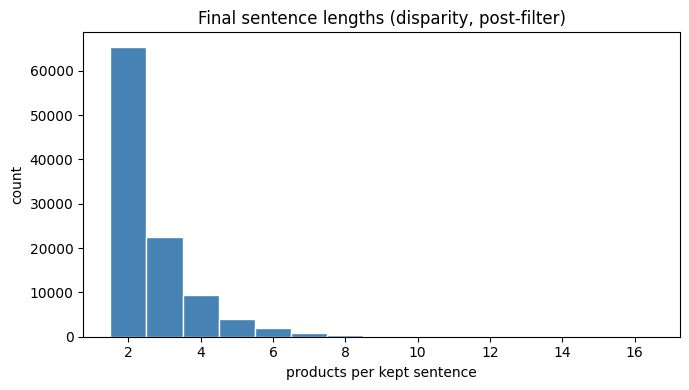

sentences kept   : 104,771
discarded (short): 295,329/400,100 (73.8%)
sentence length mean/median/max: 2.67 / 2 / 16


In [9]:
sent_lengths = [len(s["sentence"]) for s in kept_sentences]

fig, ax = plt.subplots(figsize=(7, 4))
if sent_lengths:
    ax.hist(sent_lengths, bins=range(min_sentence_length, max(sent_lengths) + 2),
            align="left", color="steelblue", edgecolor="white")
ax.set_title("Final sentence lengths (disparity, post-filter)")
ax.set_xlabel("products per kept sentence"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

print(f"sentences kept   : {len(kept_sentences):,}")
print(f"discarded (short): {n_discarded:,}/{n_total:,} "
      f"({100 * n_discarded / max(n_total, 1):.1f}%)")
if sent_lengths:
    print(f"sentence length mean/median/max: "
          f"{np.mean(sent_lengths):.2f} / {int(np.median(sent_lengths))} / {max(sent_lengths)}")

### Example walks

A handful of full walks for manual inspection: anchor, the raw path (every bridge the walk crossed), and the sentence the filter kept from it.

In [10]:
kept_filtered = [x for x in filtered if len(x["sentence"]) >= min_sentence_length]
display_rng = np.random.default_rng(0)
picks = (display_rng.choice(len(kept_filtered),
                            size=min(10, len(kept_filtered)), replace=False)
         if kept_filtered else [])

for i in picks:
    x = kept_filtered[int(i)]
    print("anchor   :", name(x["anchor_id"]))
    print("raw path :", " -> ".join(names(x["raw_path"])))
    print("sentence :", " -> ".join(names(x["sentence"])))
    print("hops     :", x["hops_taken"])
    print("-" * 90)

anchor   : Beet Goes On Vegetable & Fruit Drink
raw path : Beet Goes On Vegetable & Fruit Drink -> Beet Apple Carrot Lemon Ginger Organic Cold Pressed Juice Beverage -> Honeycrisp Apple -> Banana -> California Veggie Burgers - 4 CT -> Vitamin Water Zero Squeezed Lemonade -> Bag of Organic Bananas -> Watermelon Chunks -> Cucumber Kirby -> Organic Baby Spinach -> First Prunes -> Large Lemon -> Apple Honeycrisp Organic -> Garnet Sweet Potato (Yam) -> Limes -> Organic Lemon
sentence : Beet Goes On Vegetable & Fruit Drink -> Beet Apple Carrot Lemon Ginger Organic Cold Pressed Juice Beverage
hops     : 15
------------------------------------------------------------------------------------------
anchor   : Mixed Jumbo Raisins
raw path : Mixed Jumbo Raisins -> Red Kidney Beans -> 100% Natural Diced Tomatoes -> Sweet Cream Salted Butter -> All Natural Regular Pork Sausage -> Organic Basil -> Cherubs Heavenly Salad Tomatoes -> Cranberry Almond Plus Antioxidants 1.4 oz Fruit & Nut Bars -> Organic

## 8. Rank novelty — does the filter surface *new* substitutes?

For each stress-test anchor, look at every product its kept sentences surfaced and find where that product sits in Step 1's own full similarity ranking for the anchor (rank 1 = Step 1's nearest neighbour). Anything inside Step 1's top-10 is flagged "not new" — the walk + filter earns its keep only when it surfaces genuine substitutes ranked *far down* that list.

In [11]:
surfaced = {pid: Counter() for pid in STRESS_TEST_IDS}
for s in kept_sentences:
    a = s["anchor_id"]
    if a in surfaced:
        for p in s["sentence"]:
            if p != a:
                surfaced[a][p] += 1

# Compute each anchor's full similarity vector + rank lookup ONCE, then reuse it
# across all of that anchor's surfaced targets (instead of re-ranking per target).
print("Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?")
print("=" * 70)
for pid, nm in STRESS_TEST_IDS.items():
    if pid not in pid_to_idx:
        print(f"\n{nm} ({pid}) — not in catalogue, skipped")
        continue
    sims = embeddings @ embeddings[pid_to_idx[pid]]        # cosine vs anchor (unit-norm)
    ranks = np.empty(len(sims), dtype=int)
    ranks[np.argsort(-sims)] = np.arange(len(sims))        # rank[idx]: 0 = anchor, 1 = #1 neighbour
    print(f"\n{nm} ({pid})")
    surfaced_here = surfaced.get(pid, Counter())
    if not surfaced_here:
        print("  (no substitutes surfaced)")
    for p, c in surfaced_here.most_common():
        idx = pid_to_idx[p]
        rank = int(ranks[idx])
        flag = "  <- inside Step 1's own top-10, not new" if rank <= 10 else ""
        print(f"  {c}x  {name(p):<45} rank={rank:>6}  sim={sims[idx]:.3f}{flag}")

Rank novelty: where do the filter's discoveries sit in Step 1's own ranking?

Whole Milk (4210)
  (no substitutes surfaced)

Unsweetened Almond Milk (6347)
  10x  Organic Whole Milk                            rank=   345  sim=0.751
  6x  Organic Unsweetened Almond Milk               rank=     7  sim=0.962  <- inside Step 1's own top-10, not new
  5x  Unsweetened Almondmilk                        rank=     1  sim=0.982  <- inside Step 1's own top-10, not new
  5x  Whole Milk                                    rank=   393  sim=0.736
  3x  Toasted Coconut Almondmilk Blend              rank=    98  sim=0.872
  2x  Organic Coconut Milk                          rank=   106  sim=0.864
  2x  Reduced Fat Milk 100% Lactose Free            rank=   205  sim=0.808
  2x  Unsalted Butter                               rank=   483  sim=0.720
  2x  Organic Skim Milk                             rank=   398  sim=0.736
  1x  Organic Nonfat Milk                           rank=   332  sim=0.753
  1x  Vanilla

## 9. Background popularity check

How common is each surfaced product overall? A "substitute" that appears in a huge fraction of baskets may just be popular rather than genuinely related. We read the per-product basket counts straight from `product_basket_freq.json` — no basket graph to rebuild.

In [12]:
print("Background popularity check: how common is each surfaced product overall?")
print("=" * 70)

for pid, nm in STRESS_TEST_IDS.items():
    anchor_freq = product_basket_count.get(pid, 0)
    anchor_pct = 100 * anchor_freq / total_baskets if total_baskets else 0
    print(f"\n{nm} ({pid}) — anchor itself appears in "
          f"{anchor_freq:,} / {total_baskets:,} baskets ({anchor_pct:.1f}%)")
    for p, c in surfaced.get(pid, Counter()).most_common(10):
        bg_freq = product_basket_count.get(p, 0)
        bg_pct = 100 * bg_freq / total_baskets if total_baskets else 0
        print(f"  {c}x found   {name(p):<40} appears in "
              f"{bg_freq:>7,} / {total_baskets:,} baskets ({bg_pct:.1f}%)")

Background popularity check: how common is each surfaced product overall?

Whole Milk (4210) — anchor itself appears in 11,103 / 1,000,000 baskets (1.1%)

Unsweetened Almond Milk (6347) — anchor itself appears in 1,989 / 1,000,000 baskets (0.2%)
  10x found   Organic Whole Milk                       appears in  42,879 / 1,000,000 baskets (4.3%)
  6x found   Organic Unsweetened Almond Milk          appears in  17,836 / 1,000,000 baskets (1.8%)
  5x found   Unsweetened Almondmilk                   appears in  15,486 / 1,000,000 baskets (1.5%)
  5x found   Whole Milk                               appears in  11,103 / 1,000,000 baskets (1.1%)
  3x found   Toasted Coconut Almondmilk Blend         appears in   3,928 / 1,000,000 baskets (0.4%)
  2x found   Organic Coconut Milk                     appears in   8,507 / 1,000,000 baskets (0.9%)
  2x found   Reduced Fat Milk 100% Lactose Free       appears in   3,042 / 1,000,000 baskets (0.3%)
  2x found   Unsalted Butter                         

## 10. Adaptive vs fixed theta — the stress-test anchors

Each stress-test anchor's computed adaptive `theta` next to constant_theta's fixed 0.70. "stricter" means a higher bar than the baseline (fewer winners logged), "looser" a lower one. The last two columns show the anchor's degree `k` and how many of its edges were significant (`n_significant`, or "fallback" where none were and the baseline was used instead).

In [13]:
print(f"Adaptive theta vs constant baseline ({CONSTANT_THETA_BASELINE}) — stress-test anchors")
print("=" * 94)
print(f"{'anchor':<30}{'adaptive':>9}{'fixed':>8}{'delta':>9}{'k':>8}{'n_signif':>10}  regime")
print("-" * 94)
for pid, nm in STRESS_TEST_IDS.items():
    t = anchor_thresholds.get(pid)
    if t is None:
        print(f"{nm:<30}{'(not walked / no threshold)':>38}")
        continue
    theta_a = t["theta"]
    delta = theta_a - CONSTANT_THETA_BASELINE
    if theta_a > CONSTANT_THETA_BASELINE:
        regime = "stricter"
    elif theta_a < CONSTANT_THETA_BASELINE:
        regime = "looser"
    else:
        regime = "equal"
    nsig = "fallback" if t["fallback"] else str(t["n_significant"])
    print(f"{nm:<30}{theta_a:>9.3f}{CONSTANT_THETA_BASELINE:>8.2f}{delta:>+9.3f}"
          f"{t['k']:>8}{nsig:>10}  {regime}")

Adaptive theta vs constant baseline (0.7) — stress-test anchors
anchor                         adaptive   fixed    delta       k  n_signif  regime
----------------------------------------------------------------------------------------------
Whole Milk                        0.984    0.70   +0.284   49667         1  stricter
Unsweetened Almond Milk           0.700    0.70   +0.000   49592  fallback  equal
Organic Salted Butter             0.700    0.70   +0.000   49658  fallback  equal
Vegan Butter                      0.700    0.70   +0.000   49620  fallback  equal
Whole Milk Plain Yogurt           0.915    0.70   +0.215   49593         9  stricter
Coconut Yogurt                    0.700    0.70   +0.000   49630  fallback  equal


## 11. Theta distribution across all anchors

The adaptive thresholds across every walked anchor, with the fixed 0.70 baseline marked (right of the line = stricter than the fixed method, left = looser). Alongside it, the degree `k` distribution — how many positive-similarity edges each anchor's local network has. That pairing is what actually explains the theta numbers here, the same role `knee_rank` played for Kneedle: a high-degree anchor needs a much larger share `p_j` for any single edge to look significant, which pushes its `theta` up.

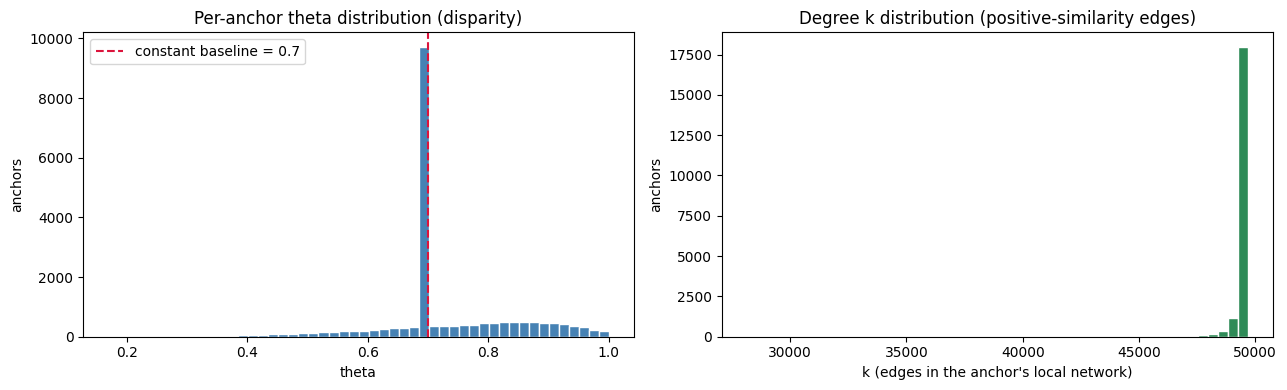

anchors with a threshold             : 20,005
stricter than 0.7 (theta > baseline)   : 7,189 (35.9%)
looser  than 0.7 (theta < baseline)   : 3,432 (17.2%)
exactly 0.7 (includes fallbacks)     : 9,384
degree k min/median/max              : 28144 / 49610 / 49686


In [14]:
thetas = np.array([t["theta"] for t in anchor_thresholds.values()])
n_stricter = int((thetas > CONSTANT_THETA_BASELINE).sum())   # higher bar than the fixed baseline
n_looser = int((thetas < CONSTANT_THETA_BASELINE).sum())
n_equal = int((thetas == CONSTANT_THETA_BASELINE).sum())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# Left: theta distribution vs the fixed baseline.
if len(thetas):
    ax[0].hist(thetas, bins=50, color="steelblue", edgecolor="white")
ax[0].axvline(CONSTANT_THETA_BASELINE, color="crimson", linestyle="--", linewidth=1.5,
              label=f"constant baseline = {CONSTANT_THETA_BASELINE}")
ax[0].set_title("Per-anchor theta distribution (disparity)")
ax[0].set_xlabel("theta"); ax[0].set_ylabel("anchors")
ax[0].legend()

# Right: degree (k) distribution across all anchors — this is what explains the thetas.
ks = np.array([t["k"] for t in anchor_thresholds.values()])
if len(ks):
    ax[1].hist(ks, bins=50, color="seagreen", edgecolor="white")
ax[1].set_title("Degree k distribution (positive-similarity edges)")
ax[1].set_xlabel("k (edges in the anchor's local network)"); ax[1].set_ylabel("anchors")

plt.tight_layout(); plt.show()

print(f"anchors with a threshold             : {len(thetas):,}")
print(f"stricter than {CONSTANT_THETA_BASELINE} (theta > baseline)   : {n_stricter:,} "
      f"({100 * n_stricter / max(len(thetas), 1):.1f}%)")
print(f"looser  than {CONSTANT_THETA_BASELINE} (theta < baseline)   : {n_looser:,} "
      f"({100 * n_looser / max(len(thetas), 1):.1f}%)")
if n_equal:
    print(f"exactly {CONSTANT_THETA_BASELINE} (includes fallbacks)     : {n_equal:,}")
if len(ks):
    print(f"degree k min/median/max              : {ks.min()} / "
          f"{int(np.median(ks))} / {ks.max()}")

---
## 12. Transform filtered walks into human-readable format

In [15]:
readable_path = FILTER_DIR / "walk_sentences_readable.txt"
prev_anchor = None
with open(readable_path, "w") as f:
    for s in kept_sentences:
        if s["anchor_id"] != prev_anchor:
            if prev_anchor is not None:
                f.write("\n")
            prev_anchor = s["anchor_id"]
        f.write(f"[{s['anchor_id']}] " + " -> ".join(names(s["sentence"])) + "\n")

print(f"Saved {readable_path.name} ({len(kept_sentences):,} lines across "
      f"{len({s['anchor_id'] for s in kept_sentences}):,} anchors)")

Saved walk_sentences__disparity_readable.txt (104,771 lines across 14,685 anchors)
